# Environment

## Imports

In [1]:
import os
import time
import warnings
from itertools import product

import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
import scanpy as sc
import numpy as np
import cupy as cp
import rapids_singlecell as rsc
from scipy import sparse

## Global variables

In [2]:
warnings.filterwarnings("ignore")

In [3]:
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

## Load the data

In [4]:
%%time
adata = sc.read_10x_h5(
    os.path.join("data", "pbmc10k.h5")
)
adata.var = (
    adata.var
    .reset_index(names="gene_name")
    .set_index("gene_ids", drop=False)
)

adata

CPU times: user 884 ms, sys: 164 ms, total: 1.05 s
Wall time: 1.05 s


AnnData object with n_obs × n_vars = 10985 × 36601
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome'

In [5]:
scanpy_pca_embedding = np.load(
    os.path.join("results", "pbmc10k_scanpy_pca_embedding.npy")
)

In [6]:
scanpy_distances = sparse.load_npz(
    os.path.join("results", "pbmc10k_scanpy_distances.npz")
)

scanpy_connectivities = sparse.load_npz(
    os.path.join("results", "pbmc10k_scanpy_connectivities.npz")
)

In [7]:
%%time
rsc.get.anndata_to_GPU(adata)

CPU times: user 29.2 ms, sys: 92 ms, total: 121 ms
Wall time: 120 ms


# Processing

## QC

In [8]:
adata.var["mt"] = adata.var.gene_name.str.startswith("MT-")
adata.var["ribo"] = adata.var.gene_name.str.startswith(("RPS", "RPL"))

In [9]:
%%time
rsc.pp.calculate_qc_metrics(
    adata,
    expr_type="counts",
    var_type="genes",
    qc_vars=["mt", "ribo"],
    log1p=True,
    layer=None
)

adata

CPU times: user 30.1 ms, sys: 0 ns, total: 30.1 ms
Wall time: 34.8 ms


AnnData object with n_obs × n_vars = 10985 × 36601
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts'

... storing 'gene_name' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


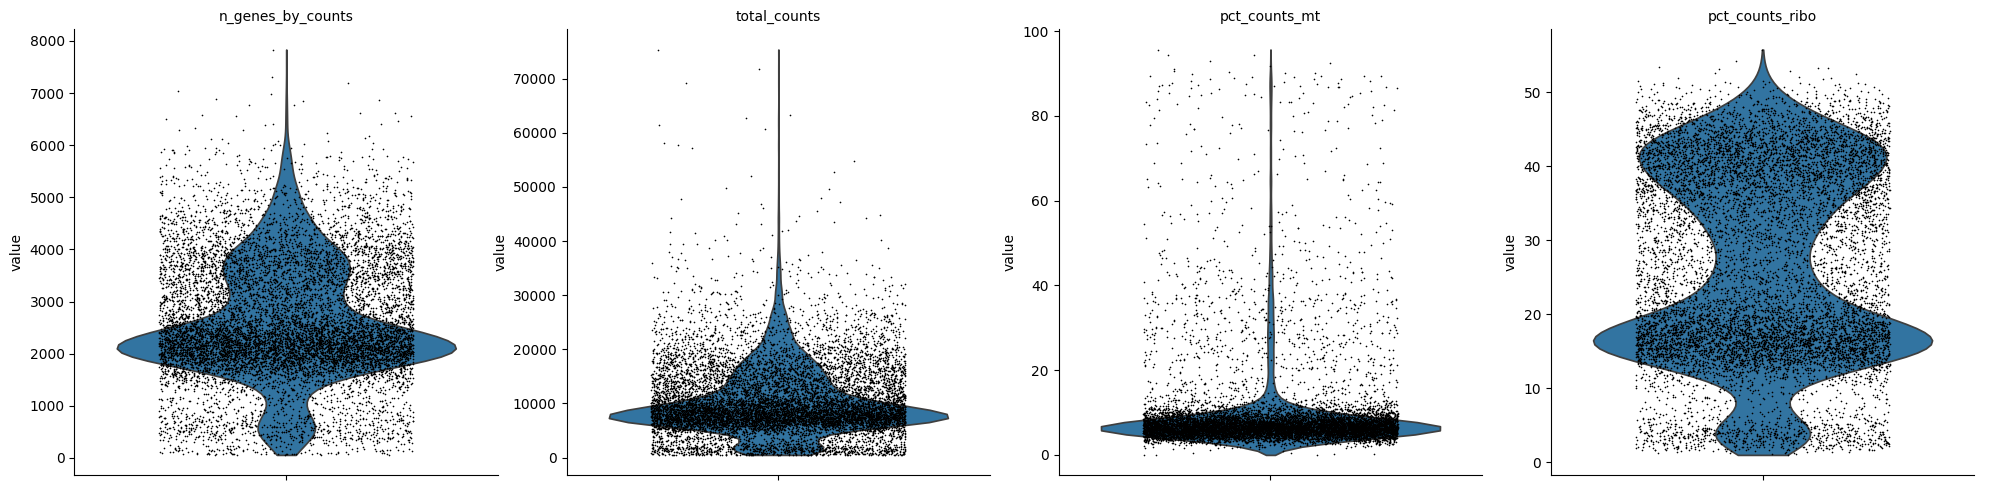

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.3,
    size=1.2,
    multi_panel=True
)

In [11]:
filter_condition = (adata.obs["n_genes_by_counts"] < 5000) & (adata.obs["pct_counts_mt"] < 20)
adata = adata[filter_condition]
print(f"Filtered {(~filter_condition).sum()} cells")

Filtered 1107 cells


In [12]:
%%time
rsc.pp.filter_genes(adata, min_cells=5)

filtered out 15480 genes that are detected in less than 5 cells
CPU times: user 107 ms, sys: 83.7 ms, total: 191 ms
Wall time: 235 ms


In [13]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells'

## Normalize

In [14]:
%%time
rsc.pp.normalize_total(
    adata,
    target_sum=1e4,
    exclude_highly_expressed=False,
    layer=None,
    inplace=True
)

CPU times: user 1.42 ms, sys: 93 μs, total: 1.51 ms
Wall time: 1.7 ms


In [15]:
%%time
rsc.pp.log1p(
    adata,
    base=None,
    obsm=None,
    layer=None,
    inplace=True
)

CPU times: user 4.01 ms, sys: 4.4 ms, total: 8.41 ms
Wall time: 7.94 ms


In [16]:
%%time
rsc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    max_disp=np.inf,
    flavor="cell_ranger",
    n_bins=20,
    span=0.3,
    layer=None,
)

CPU times: user 22.8 ms, sys: 3.92 ms, total: 26.7 ms
Wall time: 28.2 ms


## Clustering

In [17]:
%%time
pairs = list(product(
    range(3),
    ["covariance_eigh", "lanczos", "randomized"],
))
for rs, solver in pairs:
    rsc.tl.pca(
        adata,
        n_comps=50,
        zero_center=True,
        svd_solver=solver,
        random_state=rs,
        use_highly_variable=True,
        chunked=False,
        layer=None,
        key_added=f"X_pca_{solver}_{rs}"
    )

adata.obsm["X_pca"] = scanpy_pca_embedding

CPU times: user 3.46 s, sys: 537 ms, total: 4 s
Wall time: 4.02 s


In [18]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'X_pca_covariance_eigh_0', 'X_pca_lanczos_0', 'X_pca_randomized_0', 'X_pca_covariance_eigh_1', 'X_pca_lanczos_1', 'X_pca_randomized_1', 'X_pca_covariance_eigh_2', 'X_pca_lanczos_2', 'X_pca_randomized_2'
    obsm: 'X_pca_covariance_eigh_0', 'X_pca_lanczos_0', 'X_pca_randomized_0', 'X_pca_covariance_eigh_1', 'X_pca_lanczos_1', 'X_pca_randomized_1', 'X_pca_covariance_eigh_2', 'X_pca_lanczos_2', 'X_pca_randomized_2', 'X_pca

For some reason `rapids-singlecell` returns 15 neighbors instead of 16. This is likely a bug in `rapids-singlecell` and should be fixed. For now, we will ignore this and just compare the 15 neighbors that are returned by both methods.

In [19]:
%%time
pairs = list(product(
    range(3),
    ["brute", "cagra", "ivfflat", "ivfpq", "nn_descent", "all_neighbors"],
))
for rs, algorithm in pairs:
    rsc.pp.neighbors(
        adata,
        n_neighbors=16,
        n_pcs=50,
        algorithm=algorithm,
        metric="euclidean",
        method="umap",
        use_rep="X_pca",
        random_state=rs,
        key_added=f"neighbors{rs}_{algorithm}"
    )

adata.obsp["distances"] = scanpy_distances
adata.obsp["connectivities"] = scanpy_connectivities
adata.uns["neighbors"] = {
    'connectivities_key': 'connectivities',
    'distances_key': 'distances',
    'params': {
        'n_neighbors': 15,
        'method': 'umap',
        'random_state': 0,
        'metric': 'euclidean',
        'use_rep': 'X_pca',
        'n_pcs': 50
    }
}

CPU times: user 12.4 s, sys: 536 ms, total: 12.9 s
Wall time: 3.51 s


In [20]:
%%time
rsc.tl.umap(
    adata,
    min_dist=0.5,
    spread=1.0,
    n_components=2,
    maxiter=100,
    alpha=1.0,
    negative_sample_rate=5,
    init_pos="spectral",
    random_state=4,
    neighbors_key="neighbors",
)

CPU times: user 133 ms, sys: 19.9 ms, total: 153 ms
Wall time: 153 ms


In [21]:
%%time
rsc.tl.leiden(
    adata,
    resolution=1.0,
    random_state=4,
    theta=1.0,
    adjacency=None,
    n_iterations=100,
    use_weights=True,
    neighbors_key="neighbors",
    use_dask=False
)

CPU times: user 1.27 s, sys: 428 ms, total: 1.7 s
Wall time: 1.75 s


In [22]:
rsc.get.anndata_to_CPU(adata)

for key in ["X_pca", "X_umap"]:
    if key in adata.obsm and isinstance(adata.obsm[key], cp.ndarray):
        adata.obsm[key] = adata.obsm[key].get()

In [23]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'leiden'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'X_pca_covariance_eigh_0', 'X_pca_lanczos_0', 'X_pca_randomized_0', 'X_pca_covariance_eigh_1', 'X_pca_lanczos_1', 'X_pca_randomized_1', 'X_pca_covariance_eigh_2', 'X_pca_lanczos_2', 'X_pca_randomized_2', 'neighbors0_brute', 'neighbors0_cagra', 'neighbors0_ivfflat', 'neighbors0_ivfpq', 'neighbors0_nn_descent', 'neighbors0_all_neighbors', 'neighbors1_brute', 'neighbors1_cagra', 'neighbors1_ivfflat', 'neighbors1_

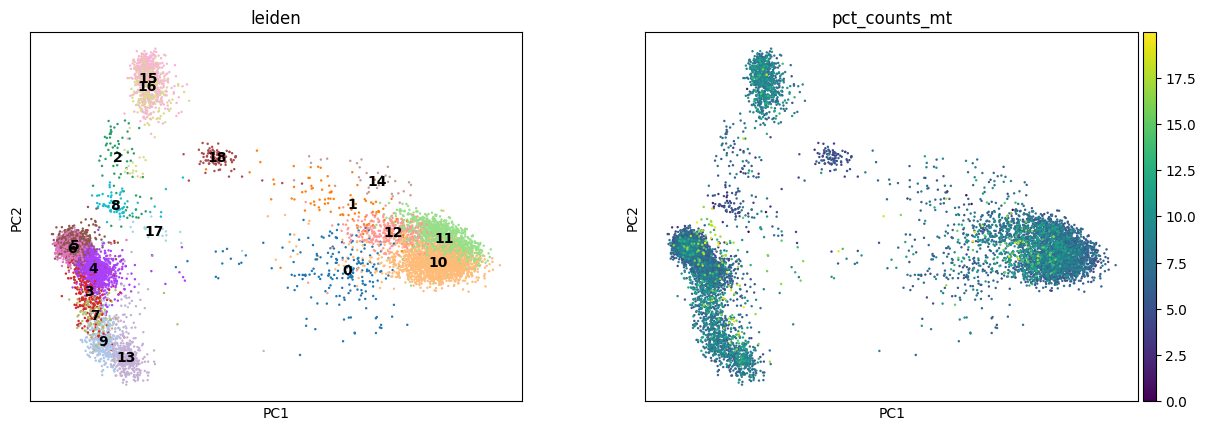

CPU times: user 191 ms, sys: 0 ns, total: 191 ms
Wall time: 190 ms


In [24]:
%%time
sc.pl.pca(adata, color=["leiden", "pct_counts_mt"], legend_loc="on data")

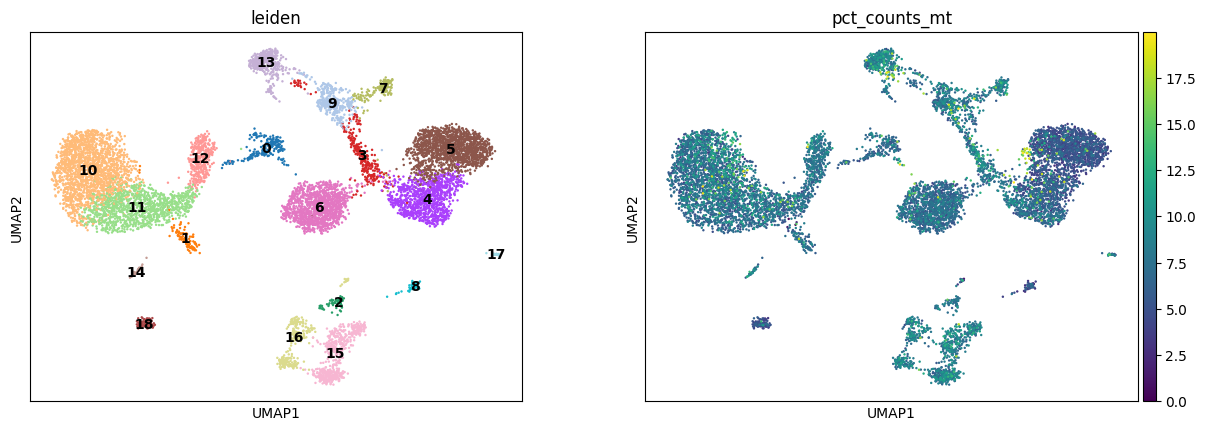

CPU times: user 182 ms, sys: 51 μs, total: 182 ms
Wall time: 181 ms


In [25]:
%%time
sc.pl.umap(adata, color=["leiden", "pct_counts_mt"], legend_loc="on data")

# Save results


In [26]:
os.makedirs("results", exist_ok=True)
adata.write(
    os.path.join("results", "pbmc10k_rapids.h5ad"),
)